# Day 5.3: Evaluation Metrics for Imbalanced Data

## Table of Contents
1. [Introduction](#introduction)
2. [Recap of Key Metrics](#recap-of-key-metrics)
   - [Confusion Matrix](#confusion-matrix)
   - [Accuracy](#accuracy)
   - [Precision](#precision)
   - [Recall](#recall)
   - [F1-Score](#f1-score)
3. [Why Standard Metrics Can Be Misleading](#why-standard-metrics-can-be-misleading)
4. [Precision-Recall (PR) Curve](#precision-recall-pr-curve)
   - [What is a PR Curve?](#what-is-a-pr-curve)
   - [Why is it Useful for Imbalanced Data?](#why-is-it-useful-for-imbalanced-data)
   - [Interpretation](#interpretation)
   - [Area Under the PR Curve (AUC-PR)](#area-under-the-pr-curve-auc-pr)
5. [PR Curves vs. ROC Curves](#pr-curves-vs-roc-curves)
6. [Other Metrics for Imbalanced Data](#other-metrics-for-imbalanced-data)
7. [Choosing the Right Metric for Your Problem](#choosing-the-right-metric-for-your-problem)
8. [Knowledge Check](#knowledge-check)
9. [Summary](#summary)

## Introduction

In previous sections, we explored the challenges of imbalanced datasets and techniques to address them. However, even with these techniques, we need appropriate evaluation metrics to understand how well our models are performing—especially on the minority class.

In this section, we'll review key evaluation metrics, understand why traditional metrics like accuracy can be misleading, and explore metrics specifically designed for imbalanced data, with a focus on the Precision-Recall curve.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    precision_recall_curve, 
    roc_curve, 
    auc, 
    average_precision_score,
    roc_auc_score,
    classification_report
)
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

Let's start by creating an imbalanced dataset that we'll use throughout this section:

In [2]:
# Create an imbalanced dataset (90% class 0, 10% class 1)
X, y = make_classification(
    n_samples=10000, 
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],
    random_state=42
)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check class distribution
print("Training set class distribution:")
print(pd.Series(y_train).value_counts(normalize=True))

Training set class distribution:
0    0.896571
1    0.103429
Name: proportion, dtype: float64


In [3]:
print("\nTest set class distribution:")
print(pd.Series(y_test).value_counts(normalize=True))


Test set class distribution:
0    0.896667
1    0.103333
Name: proportion, dtype: float64


Let's train a baseline model that we'll use to discuss evaluation metrics:

In [4]:
# Train a logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Get predictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

## Recap of Key Metrics

Before diving into more complex evaluation techniques, let's review the fundamental metrics for classification problems.

### Confusion Matrix

The confusion matrix provides a comprehensive view of model performance by showing the counts of true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN).

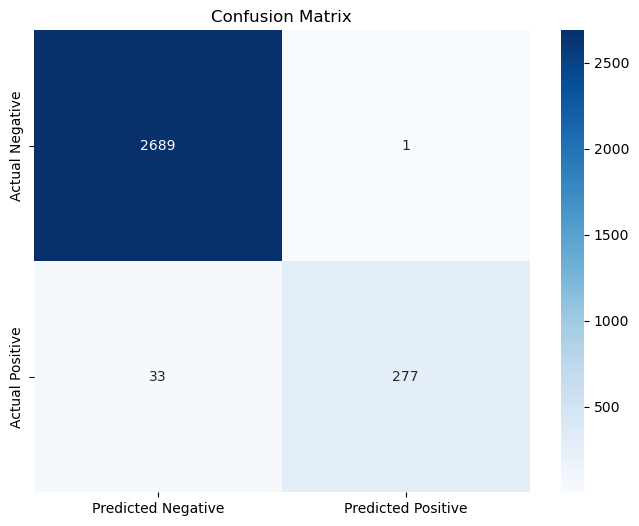

In [5]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.show()

In [6]:
# Extract values from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

True Negatives (TN): 2689
False Positives (FP): 1
False Negatives (FN): 33
True Positives (TP): 277


Let's create a visual representation of these confusion matrix components:

In [7]:
# Visualize components of confusion matrix
def plot_confusion_matrix_components():
    # Create a 2x2 grid
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create a blank 2x2 grid
    data = np.zeros((2, 2))
    
    # Create a heatmap with custom annotations
    sns.heatmap(data, annot=np.array([['TN', 'FP'], ['FN', 'TP']]),
                fmt='', cmap='Blues', cbar=False, annot_kws={"size": 20})
    
    # Add explanations in each cell
    explanations = [
        ['True Negative\nCorrectly predicted\nnegative', 'False Positive\nIncorrectly predicted\npositive'],
        ['False Negative\nIncorrectly predicted\nnegative', 'True Positive\nCorrectly predicted\npositive']
    ]
    
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.7, explanations[i][j], 
                    ha='center', va='center', fontsize=12)
    
    # Add numerical values from our model
    values = [[tn, fp], [fn, tp]]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.3, f"Count: {values[i][j]}", 
                    ha='center', va='center', fontsize=12, weight='bold')
    
    # Set labels
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.title('Confusion Matrix Components')
    
    # Set tick labels
    ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
    ax.set_yticklabels(['Negative (0)', 'Positive (1)'])
    
    plt.tight_layout()
    plt.show()

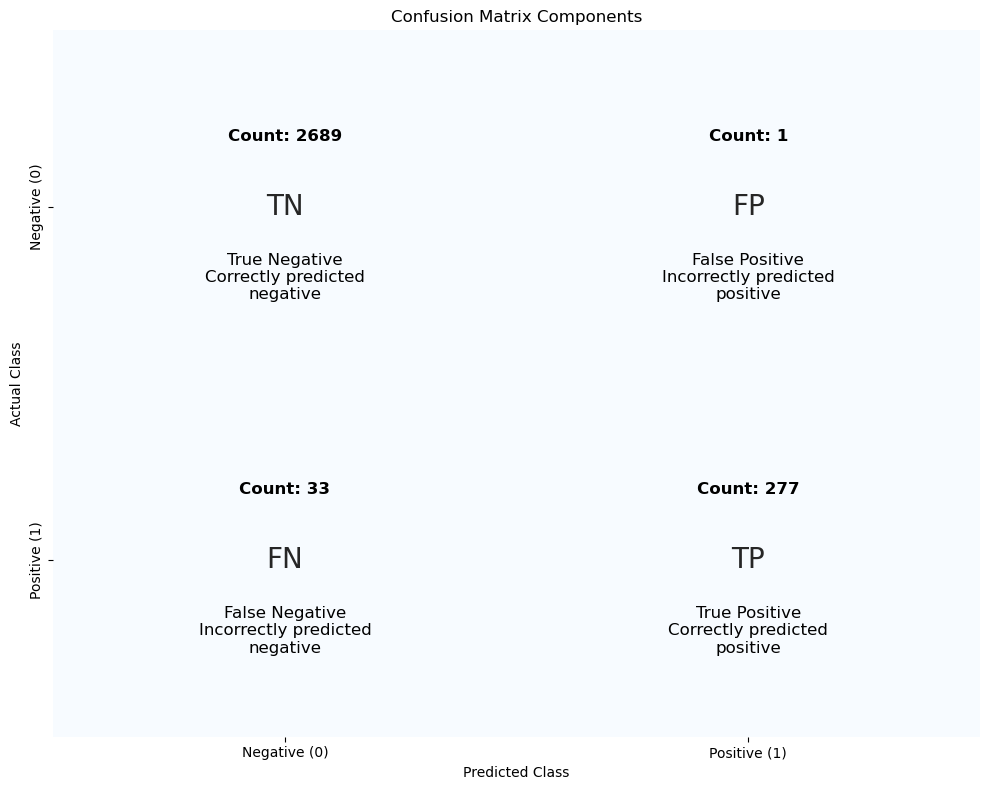

In [8]:
# Plot confusion matrix components
plot_confusion_matrix_components()

### Accuracy

Accuracy is the proportion of correct predictions (both true positives and true negatives) among the total number of predictions.

In [9]:
# Calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Calculate accuracy from confusion matrix
acc_cm = (tp + tn) / (tp + tn + fp + fn)
print(f"Accuracy (from confusion matrix): {acc_cm:.4f}")

Accuracy: 0.9887
Accuracy (from confusion matrix): 0.9887


### Precision

Precision is the proportion of true positives among all positive predictions. It measures how many of the samples predicted as positive are actually positive.

In [10]:
# Calculate precision
prec = precision_score(y_test, y_pred)
print(f"Precision: {prec:.4f}")

Precision: 0.9964


In [11]:
# Calculate precision from confusion matrix
prec_cm = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f"Precision (from confusion matrix): {prec_cm:.4f}")

Precision (from confusion matrix): 0.9964


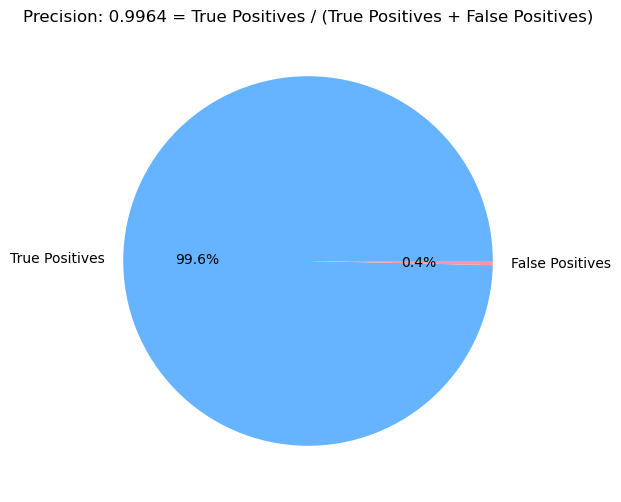

In [12]:
# Visualize precision
plt.figure(figsize=(8, 6))
plt.pie([tp, fp], labels=['True Positives', 'False Positives'], 
        autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
plt.title(f'Precision: {prec:.4f} = True Positives / (True Positives + False Positives)')
plt.show()

### Recall

Recall (also known as sensitivity or true positive rate) is the proportion of true positives among all actual positives. It measures how many of the actual positive samples are correctly identified.

In [13]:
# Calculate recall
rec = recall_score(y_test, y_pred)
print(f"Recall: {rec:.4f}")

Recall: 0.8935


In [14]:
# Calculate recall from confusion matrix
rec_cm = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"Recall (from confusion matrix): {rec_cm:.4f}")

Recall (from confusion matrix): 0.8935


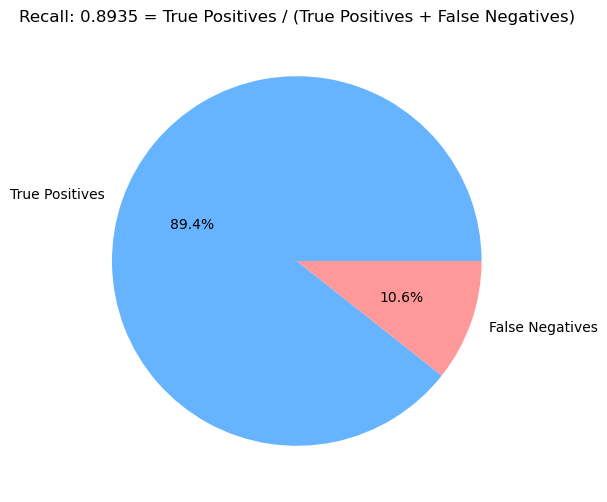

In [15]:
# Visualize recall
plt.figure(figsize=(8, 6))
plt.pie([tp, fn], labels=['True Positives', 'False Negatives'], 
        autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
plt.title(f'Recall: {rec:.4f} = True Positives / (True Positives + False Negatives)')
plt.show()

### F1-Score

The F1-score is the harmonic mean of precision and recall. It provides a balance between the two metrics.

In [16]:
# Calculate F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

F1-score: 0.9422


In [17]:
# Calculate F1-score from precision and recall
f1_manual = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
print(f"F1-score (manually calculated): {f1_manual:.4f}")

F1-score (manually calculated): 0.9422


C:\Users\solom\AppData\Local\Temp\ipykernel_26648\3318089472.py:6: RuntimeWarning: invalid value encountered in divide
  Z = 2 * X * Y / (X + Y)


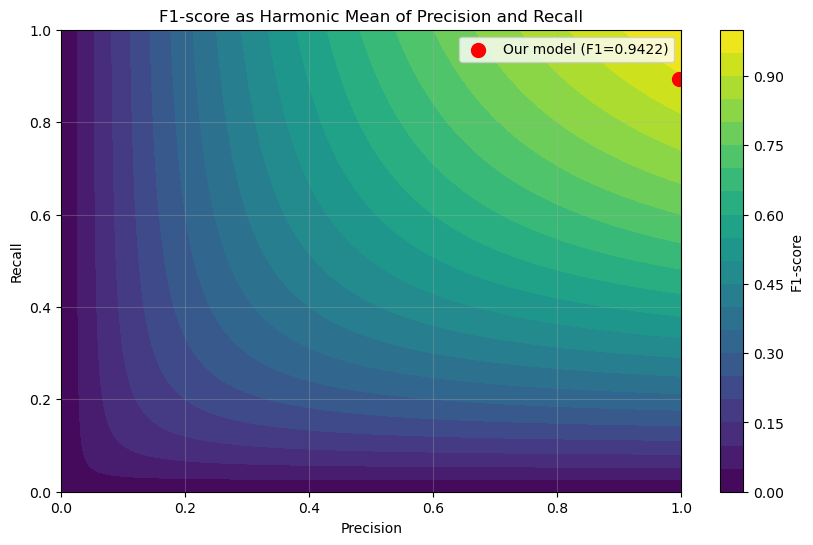

In [18]:
# Visualize F1-score as the harmonic mean of precision and recall
plt.figure(figsize=(10, 6))
x = np.linspace(0, 1, 1000)
y = np.linspace(0, 1, 1000)
X, Y = np.meshgrid(x, y)
Z = 2 * X * Y / (X + Y)
Z[np.isnan(Z)] = 0

plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(label='F1-score')
plt.scatter(prec, rec, color='red', s=100, label=f'Our model (F1={f1:.4f})')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('F1-score as Harmonic Mean of Precision and Recall')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Let's see the complete classification report for our model:

In [19]:
# Generate classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2690
           1       1.00      0.89      0.94       310

    accuracy                           0.99      3000
   macro avg       0.99      0.95      0.97      3000
weighted avg       0.99      0.99      0.99      3000



## Why Standard Metrics Can Be Misleading

In imbalanced datasets, standard metrics like accuracy can be misleading. Let's see why:

In [20]:
# Create a naive classifier that always predicts the majority class
y_pred_naive = np.zeros_like(y_test)  # Always predict class 0 (majority)

# Calculate accuracy of naive classifier
acc_naive = accuracy_score(y_test, y_pred_naive)
print(f"Naive classifier accuracy (always predict majority class): {acc_naive:.4f}")

Naive classifier accuracy (always predict majority class): 0.8967


In [21]:
# Generate complete report for naive classifier
print("\nClassification Report for Naive Classifier:")
print(classification_report(y_test, y_pred_naive))


Classification Report for Naive Classifier:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2690
           1       0.00      0.00      0.00       310

    accuracy                           0.90      3000
   macro avg       0.45      0.50      0.47      3000
weighted avg       0.80      0.90      0.85      3000



C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


As we can see, our naive classifier that always predicts the majority class achieves high accuracy but completely fails to detect the minority class (recall = 0). This is why accuracy is not an appropriate metric for imbalanced datasets.

Let's visualize the problem with accuracy:

In [ ]:
python
# Visualize why accuracy is misleading
def plot_accuracy_problem():
    # Create dummy predictions with different thresholds
    # to show how accuracy might remain high even with poor minority class detection
    thresholds = np.linspace(0, 1, 11)
    accuracies = []
    recalls = []
    precisions = []
    
    for threshold in thresholds:
        y_pred_t = (y_proba >= threshold).astype(int)
        accuracies.append(accuracy_score(y_test, y_pred_t))
        recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(thresholds, accuracies, 'b-', label='Accuracy')
    plt.plot(thresholds, recalls, 'g--', label='Recall (Minority Class)')
    plt.plot(thresholds, precisions, 'r-.', label='Precision (Minority Class)')
    plt.xlabel('Classification Threshold')
    plt.ylabel('Score')
    plt.title('Problem with Accuracy for Imbalanced Data')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Add vertical line at default threshold (0.5)
    plt.axvline(x=0.5, color='gray', linestyle=':', label='Default Threshold (0.5)')
    
    # Add annotation about how accuracy remains high even as recall drops
    plt.annotate('Accuracy remains high\neven as recall drops', 
                 xy=(0.7, 0.8), xytext=(0.5, 0.7),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))
    
    plt.show()

# Plot accuracy problem
plot_accuracy_problem()

## Precision-Recall (PR) Curve

For imbalanced datasets, the Precision-Recall (PR) curve is often more informative than standard metrics.

### What is a PR Curve?

A PR curve plots precision (y-axis) against recall (x-axis) for different classification thresholds. Each point on the curve represents the precision and recall at a specific threshold.

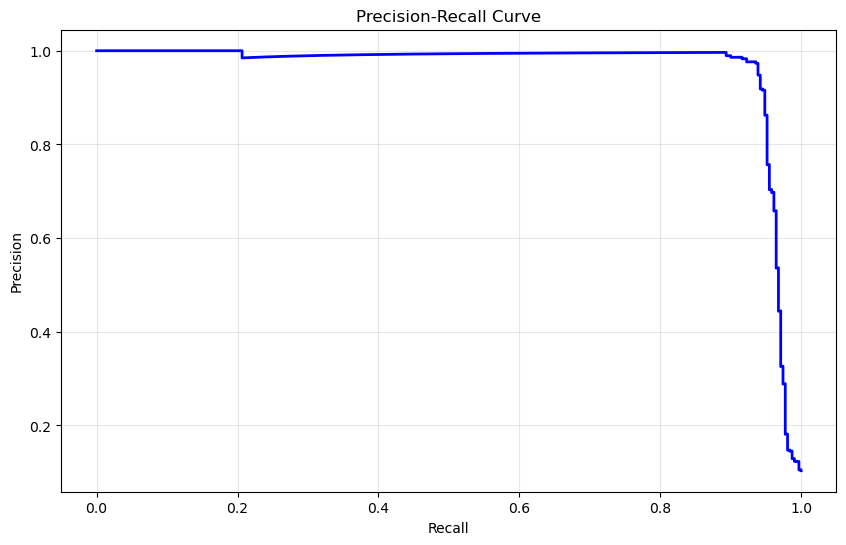

In [22]:
# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Plot PR curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, 'b-', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True, alpha=0.3)
plt.show()

### Why is it Useful for Imbalanced Data?

PR curves focus on the performance of the positive (usually minority) class. Unlike ROC curves, PR curves are not affected by the large number of true negatives in imbalanced datasets.

Let's visualize how different thresholds affect precision and recall:

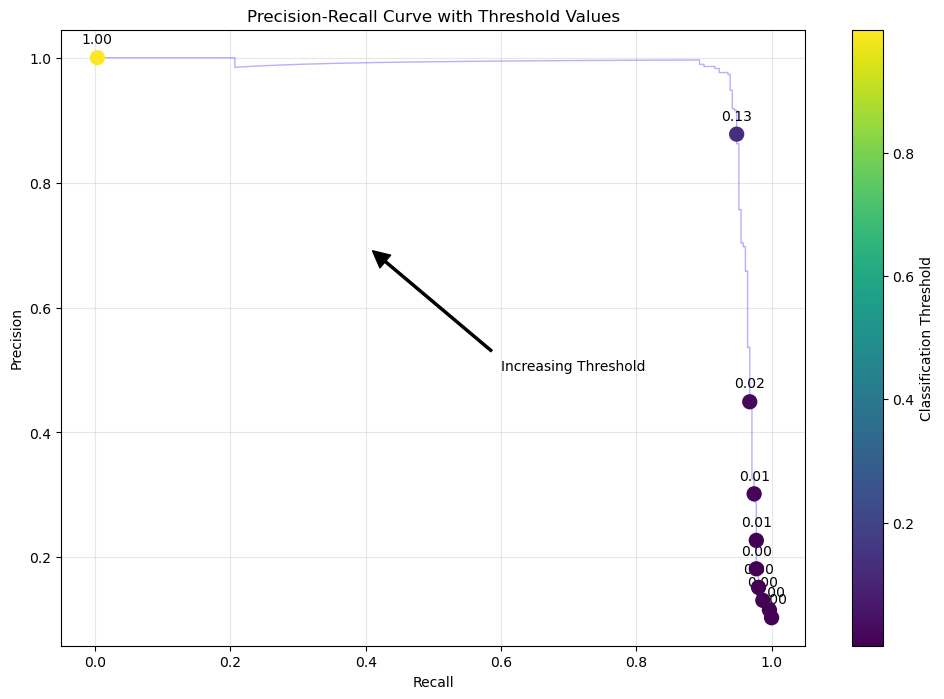

In [23]:
# Visualize threshold effect on precision and recall
def plot_threshold_effect():
    # Select a subset of thresholds for visualization
    indices = np.linspace(0, len(thresholds) - 1, 10, dtype=int)
    selected_thresholds = thresholds[indices]
    selected_precision = precision[indices]
    selected_recall = recall[indices]
    
    # Plot PR curve with threshold points
    plt.figure(figsize=(12, 8))
    
    # Plot the full PR curve
    plt.plot(recall, precision, 'b-', alpha=0.3, linewidth=1)
    
    # Plot selected threshold points
    sc = plt.scatter(selected_recall, selected_precision, 
               c=selected_thresholds, cmap='viridis', s=100, zorder=5)
    
    # Add colorbar for thresholds
    cbar = plt.colorbar(sc)
    cbar.set_label('Classification Threshold')
    
    # Add threshold annotations to selected points
    for i, (r, p, t) in enumerate(zip(selected_recall, selected_precision, selected_thresholds)):
        plt.annotate(f"{t:.2f}", (r, p), textcoords="offset points", 
                     xytext=(0, 10), ha='center')
    
    # Add arrow to show direction of increasing threshold
    plt.annotate('Increasing Threshold', xy=(0.4, 0.7), xytext=(0.6, 0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve with Threshold Values')
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot threshold effect
plot_threshold_effect()

### Interpretation

A good model has a PR curve that hugs the top-right corner of the plot, indicating high precision and high recall. A random classifier would produce a horizontal line at the level of the positive class prevalence.

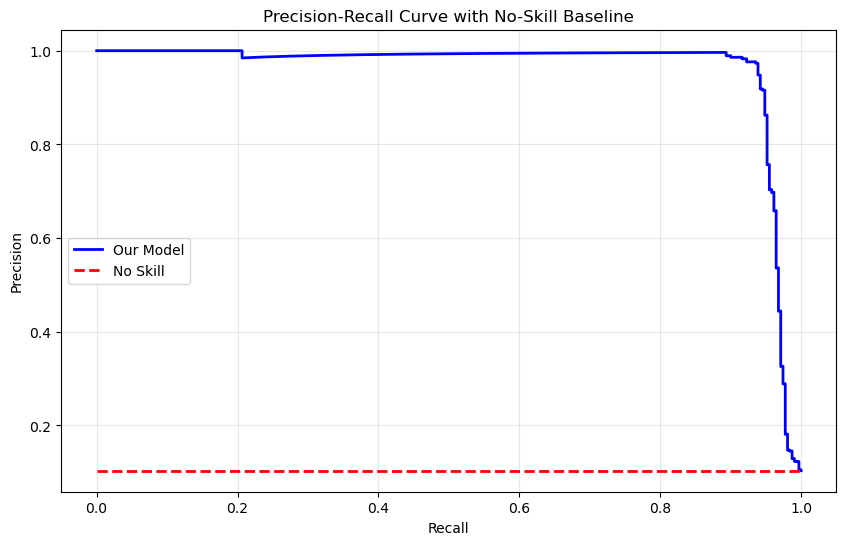

In [24]:
# Plot PR curve with baseline
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, 'b-', linewidth=2, label='Our Model')

# Add a no-skill classifier line (random guessing)
no_skill = len(y_test[y_test == 1]) / len(y_test)  # Positive class prevalence
plt.plot([0, 1], [no_skill, no_skill], 'r--', linewidth=2, label='No Skill')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with No-Skill Baseline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Area Under the PR Curve (AUC-PR)

Similar to ROC AUC, the area under the PR curve (AUC-PR) provides a single number to summarize the PR curve's performance.

Area under PR curve (AUC-PR): 0.9623


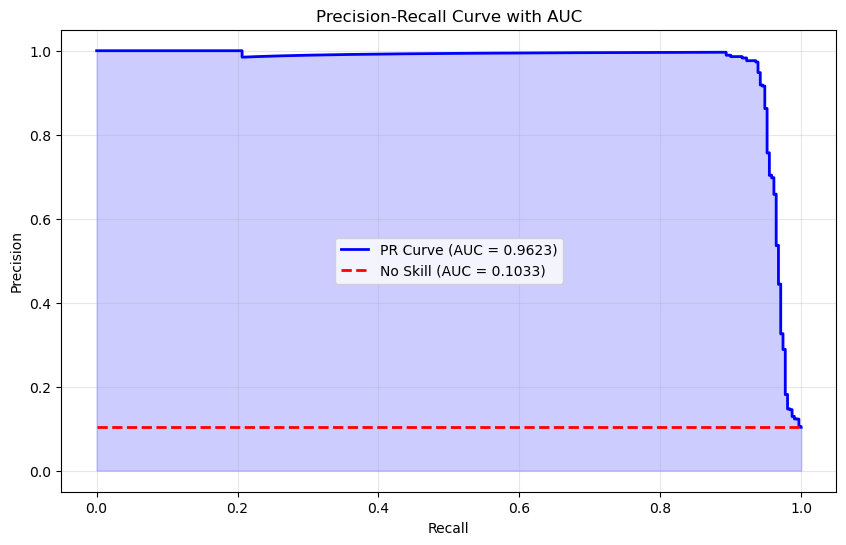

In [25]:
# Calculate area under PR curve
auc_pr = average_precision_score(y_test, y_proba)
print(f"Area under PR curve (AUC-PR): {auc_pr:.4f}")

# Visualize AUC-PR
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, 'b-', linewidth=2, label=f'PR Curve (AUC = {auc_pr:.4f})')

# Fill the area under the curve
plt.fill_between(recall, precision, alpha=0.2, color='b')

# Add no-skill line
plt.plot([0, 1], [no_skill, no_skill], 'r--', linewidth=2, label=f'No Skill (AUC = {no_skill:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with AUC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## PR Curves vs. ROC Curves

Let's compare Precision-Recall curves with Receiver Operating Characteristic (ROC) curves to understand why PR curves are preferred for imbalanced data.

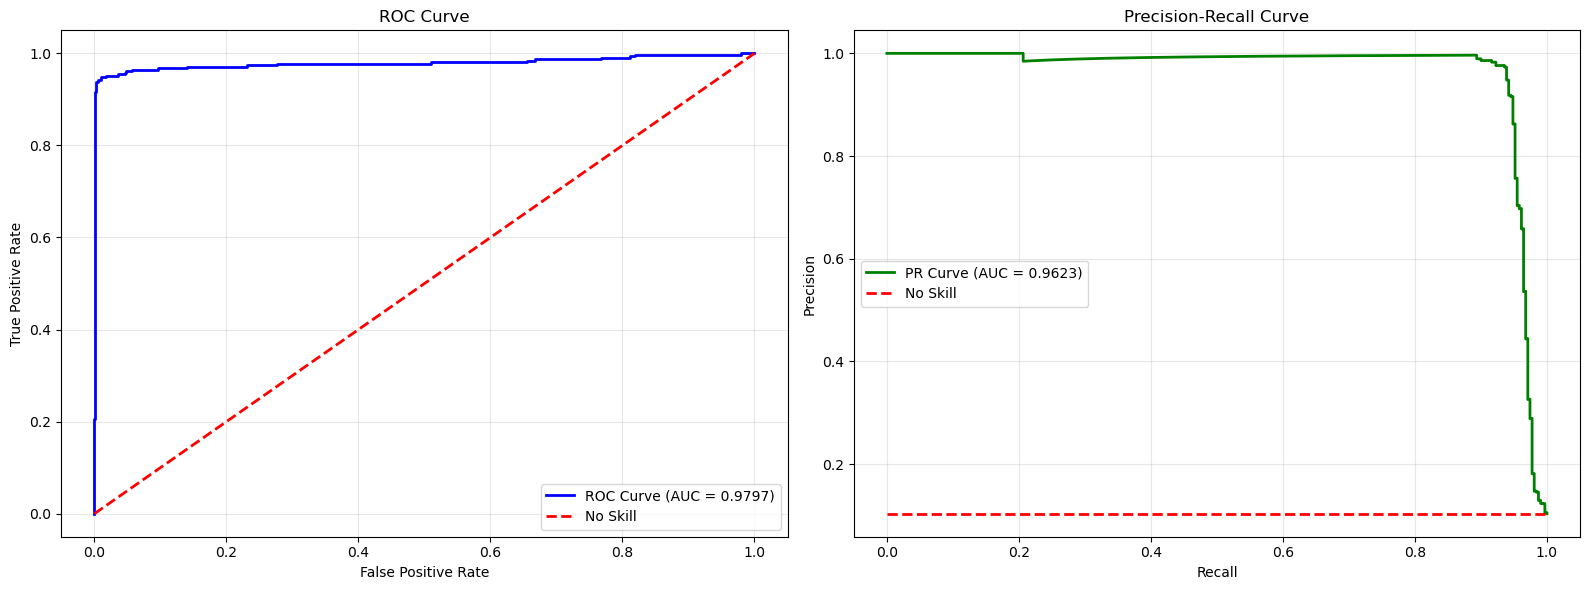

In [26]:
# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Calculate PR curve again for comparison
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auc_pr = average_precision_score(y_test, y_proba)

# Plot both curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='No Skill')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PR Curve
ax2.plot(recall, precision, 'g-', linewidth=2, label=f'PR Curve (AUC = {auc_pr:.4f})')
ax2.plot([0, 1], [no_skill, no_skill], 'r--', linewidth=2, label='No Skill')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Now, let's compare how these curves behave with different degrees of class imbalance:

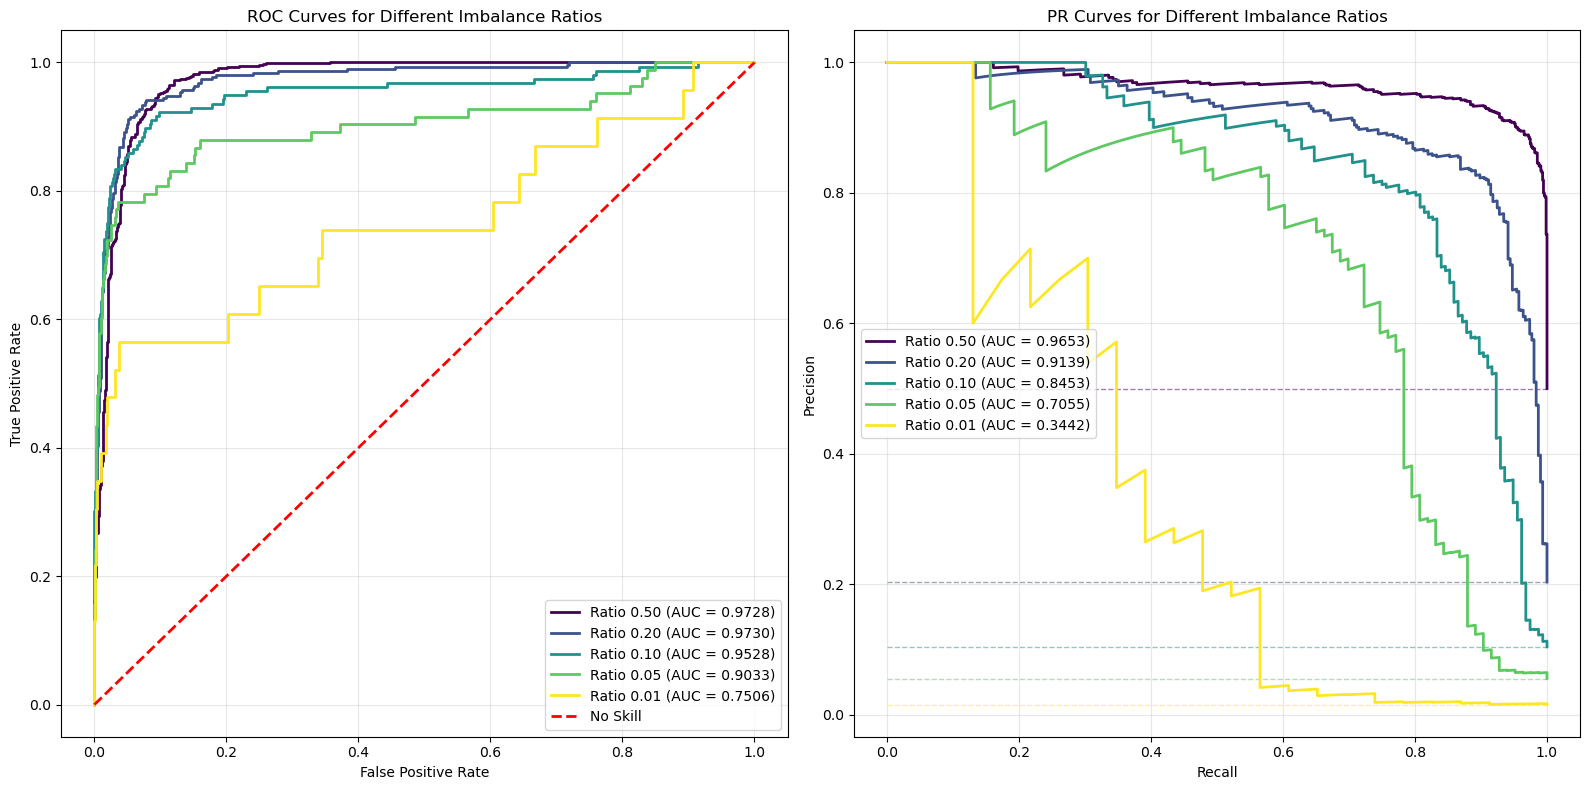

In [27]:
# Create datasets with different imbalance ratios
def create_datasets_with_imbalance():
    # List of imbalance ratios
    imbalance_ratios = [0.5, 0.2, 0.1, 0.05, 0.01]
    datasets = []
    
    for ratio in imbalance_ratios:
        # Create dataset
        X_imb, y_imb = make_classification(
            n_samples=5000,
            n_features=2,
            n_informative=2,
            n_redundant=0,
            n_repeated=0,
            n_classes=2,
            n_clusters_per_class=1,
            weights=[1-ratio, ratio],  # Class 1 has frequency = ratio
            random_state=42
        )
        
        # Split dataset
        X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
            X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
        )
        
        # Scale features
        scaler_imb = StandardScaler()
        X_train_imb_scaled = scaler_imb.fit_transform(X_train_imb)
        X_test_imb_scaled = scaler_imb.transform(X_test_imb)
        
        # Train model
        model_imb = LogisticRegression(random_state=42)
        model_imb.fit(X_train_imb_scaled, y_train_imb)
        
        # Get predictions
        y_pred_imb = model_imb.predict(X_test_imb_scaled)
        y_proba_imb = model_imb.predict_proba(X_test_imb_scaled)[:, 1]
        
        # Store dataset information
        datasets.append({
            'ratio': ratio,
            'X_test': X_test_imb_scaled,
            'y_test': y_test_imb,
            'y_pred': y_pred_imb,
            'y_proba': y_proba_imb
        })
    
    return datasets

# Create datasets with different imbalance ratios
imbalanced_datasets = create_datasets_with_imbalance()

# Compare ROC and PR curves across different imbalance ratios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Color map for different ratios
colors = plt.cm.viridis(np.linspace(0, 1, len(imbalanced_datasets)))

# Plot curves for each dataset
for i, dataset in enumerate(imbalanced_datasets):
    ratio = dataset['ratio']
    y_test_imb = dataset['y_test']
    y_proba_imb = dataset['y_proba']
    
    # Calculate ROC curve
    fpr_imb, tpr_imb, _ = roc_curve(y_test_imb, y_proba_imb)
    roc_auc_imb = roc_auc_score(y_test_imb, y_proba_imb)
    
    # Calculate PR curve
    precision_imb, recall_imb, _ = precision_recall_curve(y_test_imb, y_proba_imb)
    auc_pr_imb = average_precision_score(y_test_imb, y_proba_imb)
    
    # No skill for PR curve
    no_skill_imb = len(y_test_imb[y_test_imb == 1]) / len(y_test_imb)
    
    # Plot ROC curve
    ax1.plot(fpr_imb, tpr_imb, color=colors[i], linewidth=2, 
             label=f'Ratio {ratio:.2f} (AUC = {roc_auc_imb:.4f})')
    
    # Plot PR curve
    ax2.plot(recall_imb, precision_imb, color=colors[i], linewidth=2, 
             label=f'Ratio {ratio:.2f} (AUC = {auc_pr_imb:.4f})')
    
    # Plot no-skill line for PR curve
    ax2.plot([0, 1], [no_skill_imb, no_skill_imb], color=colors[i], linestyle='--', linewidth=1, alpha=0.5)

# Add no-skill line for ROC curve
ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='No Skill')

# Set titles and labels
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves for Different Imbalance Ratios')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('PR Curves for Different Imbalance Ratios')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As we can see, ROC curves tend to look more optimistic as imbalance increases, while PR curves clearly show the degradation in performance. This is why PR curves are more appropriate for evaluating models on imbalanced data.

## Other Metrics for Imbalanced Data

Besides PR curves, there are several other metrics that can be useful for evaluating imbalanced data:

In [28]:
# Calculate additional metrics
def calculate_additional_metrics(y_true, y_pred):
    # Extract values from confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Specificity (True Negative Rate)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Balanced Accuracy
    balanced_acc = (recall_score(y_true, y_pred) + specificity) / 2
    
    # G-mean
    g_mean = np.sqrt(recall_score(y_true, y_pred) * specificity)
    
    # Matthews Correlation Coefficient
    mcc_numerator = (tp * tn) - (fp * fn)
    mcc_denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = mcc_numerator / mcc_denominator if mcc_denominator > 0 else 0
    
    return {
        'Specificity': specificity,
        'Balanced Accuracy': balanced_acc,
        'G-mean': g_mean,
        'Matthews Correlation Coefficient': mcc
    }

# Calculate metrics for our model
additional_metrics = calculate_additional_metrics(y_test, y_pred)
for metric, value in additional_metrics.items():
    print(f"{metric}: {value:.4f}")

Specificity: 0.9996
Balanced Accuracy: 0.9466
G-mean: 0.9451
Matthews Correlation Coefficient: 0.9376


Let's create a table comparing these metrics across different models:

In [29]:
# Train different models for comparison
def train_and_evaluate_models():
    # List of models to try
    models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Logistic Regression (Balanced)': LogisticRegression(class_weight='balanced', random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'Random Forest (Balanced)': RandomForestClassifier(class_weight='balanced', random_state=42)
    }
    
    # Results storage
    results = []
    
    # Train and evaluate each model
    for name, model in models.items():
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Get predictions
        y_pred_model = model.predict(X_test_scaled)
        y_proba_model = model.predict_proba(X_test_scaled)[:, 1]
        
        # Calculate basic metrics
        accuracy = accuracy_score(y_test, y_pred_model)
        precision = precision_score(y_test, y_pred_model)
        recall = recall_score(y_test, y_pred_model)
        f1 = f1_score(y_test, y_pred_model)
        
        # Calculate additional metrics
        add_metrics = calculate_additional_metrics(y_test, y_pred_model)
        
        # Calculate AUC values
        roc_auc = roc_auc_score(y_test, y_proba_model)
        pr_auc = average_precision_score(y_test, y_proba_model)
        
        # Store results
        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'Specificity': add_metrics['Specificity'],
            'Balanced Accuracy': add_metrics['Balanced Accuracy'],
            'G-mean': add_metrics['G-mean'],
            'MCC': add_metrics['Matthews Correlation Coefficient'],
            'ROC AUC': roc_auc,
            'PR AUC': pr_auc
        })
    
    return pd.DataFrame(results)

# Generate metrics comparison table
metrics_comparison = train_and_evaluate_models()
print(metrics_comparison.to_string(index=False))

                         Model  Accuracy  Precision   Recall  F1 Score  Specificity  Balanced Accuracy   G-mean      MCC  ROC AUC   PR AUC
           Logistic Regression  0.988667   0.996403 0.893548  0.942177     0.999628           0.946588 0.945101 0.937622 0.979706 0.962325
Logistic Regression (Balanced)  0.981333   0.880240 0.948387  0.913043     0.985130           0.966759 0.966584 0.903392 0.979770 0.962666
                 Random Forest  0.992667   0.993151 0.935484  0.963455     0.999257           0.967370 0.966845 0.959914 0.980413 0.960288
      Random Forest (Balanced)  0.992667   0.989796 0.938710  0.963576     0.998885           0.968797 0.968330 0.959919 0.979089 0.959146


Let's visualize this comparison:

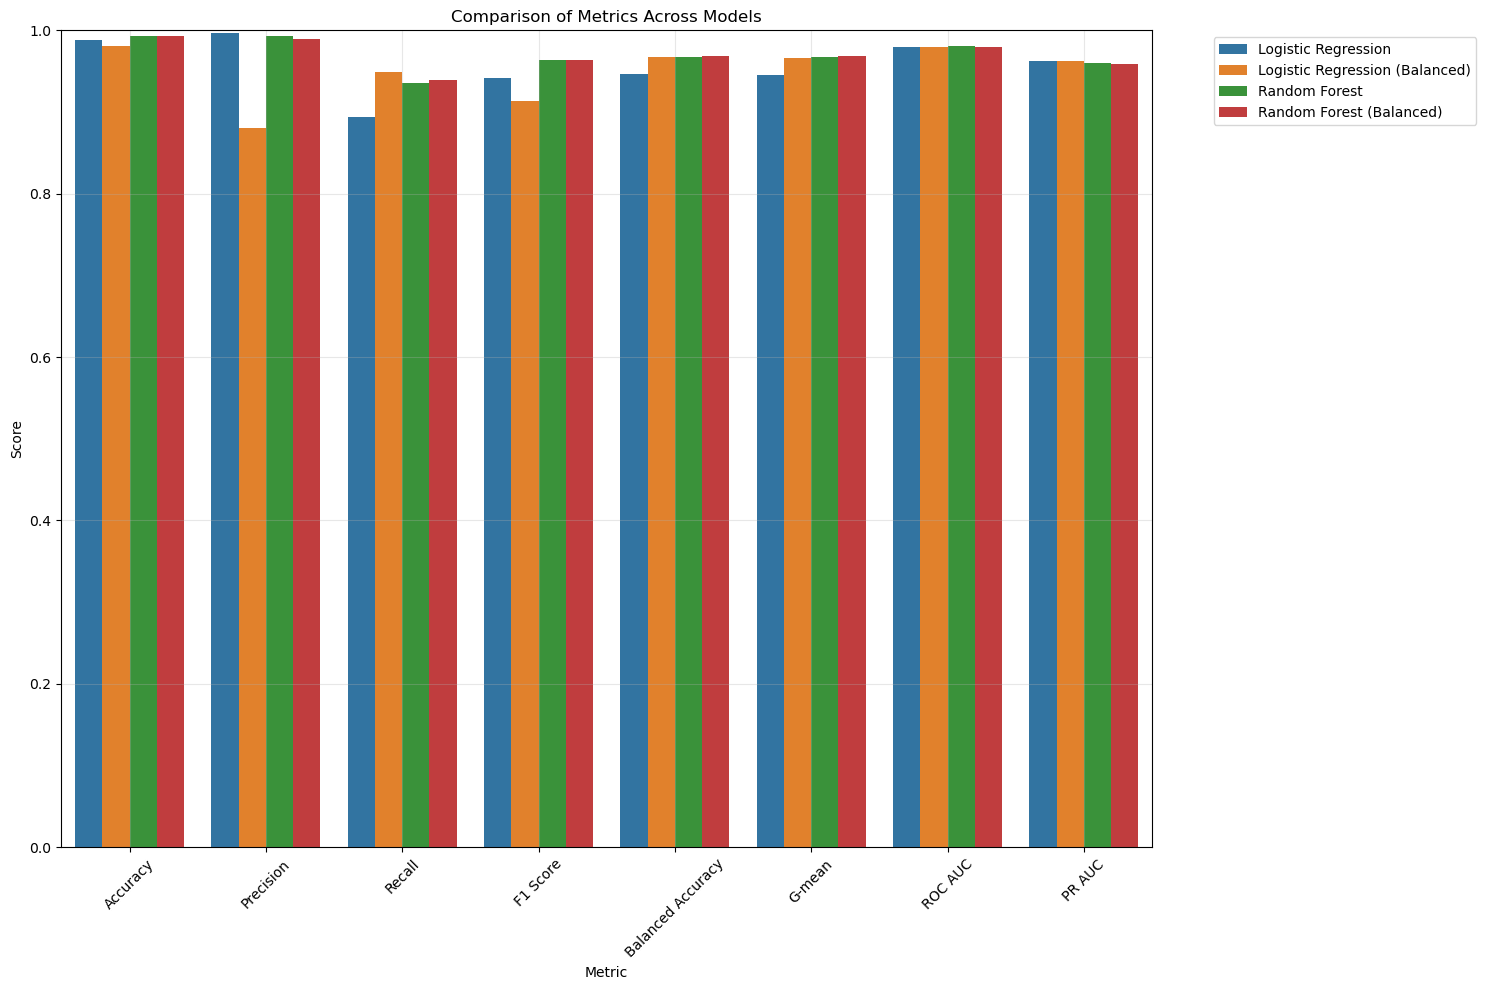

In [30]:
# Visualize metrics comparison
def plot_metrics_comparison(metrics_df):
    # Select metrics to plot
    plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 
                    'Balanced Accuracy', 'G-mean', 'ROC AUC', 'PR AUC']
    
    # Create a long-form dataframe for seaborn
    plot_data = []
    for _, row in metrics_df.iterrows():
        model = row['Model']
        for metric in plot_metrics:
            plot_data.append({
                'Model': model,
                'Metric': metric,
                'Value': row[metric]
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Plot
    plt.figure(figsize=(15, 10))
    sns.barplot(x='Metric', y='Value', hue='Model', data=plot_df)
    plt.title('Comparison of Metrics Across Models')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot metrics comparison
plot_metrics_comparison(metrics_comparison)

## Choosing the Right Metric for Your Problem

The choice of evaluation metric depends on the specific problem and the relative costs of different types of errors:

In [31]:
# Create a table of metric recommendations
metric_recommendations = pd.DataFrame({
    'Scenario': [
        'Fraud Detection',
        'Disease Diagnosis',
        'Spam Filtering',
        'Credit Risk Assessment',
        'Customer Churn Prediction'
    ],
    'Primary Metric': [
        'Recall / PR AUC',
        'Recall / F1-Score',
        'Precision / F1-Score',
        'PR AUC / MCC',
        'Balanced Accuracy / G-mean'
    ],
    'Reasoning': [
        'Missing a fraud case (FN) is very costly',
        'Missing a disease case (FN) can be life-threatening',
        'Filtering legitimate emails as spam (FP) is annoying to users',
        'Need to balance risk of default (FN) with opportunity cost of declining good customers (FP)',
        'Need to accurately identify churn risk while avoiding false alarms'
    ]
})

print(metric_recommendations.to_string(index=False))

                 Scenario             Primary Metric                                                                                   Reasoning
          Fraud Detection            Recall / PR AUC                                                    Missing a fraud case (FN) is very costly
        Disease Diagnosis          Recall / F1-Score                                         Missing a disease case (FN) can be life-threatening
           Spam Filtering       Precision / F1-Score                               Filtering legitimate emails as spam (FP) is annoying to users
   Credit Risk Assessment               PR AUC / MCC Need to balance risk of default (FN) with opportunity cost of declining good customers (FP)
Customer Churn Prediction Balanced Accuracy / G-mean                          Need to accurately identify churn risk while avoiding false alarms


Let's visualize how different business scenarios might prioritize different aspects of model performance:

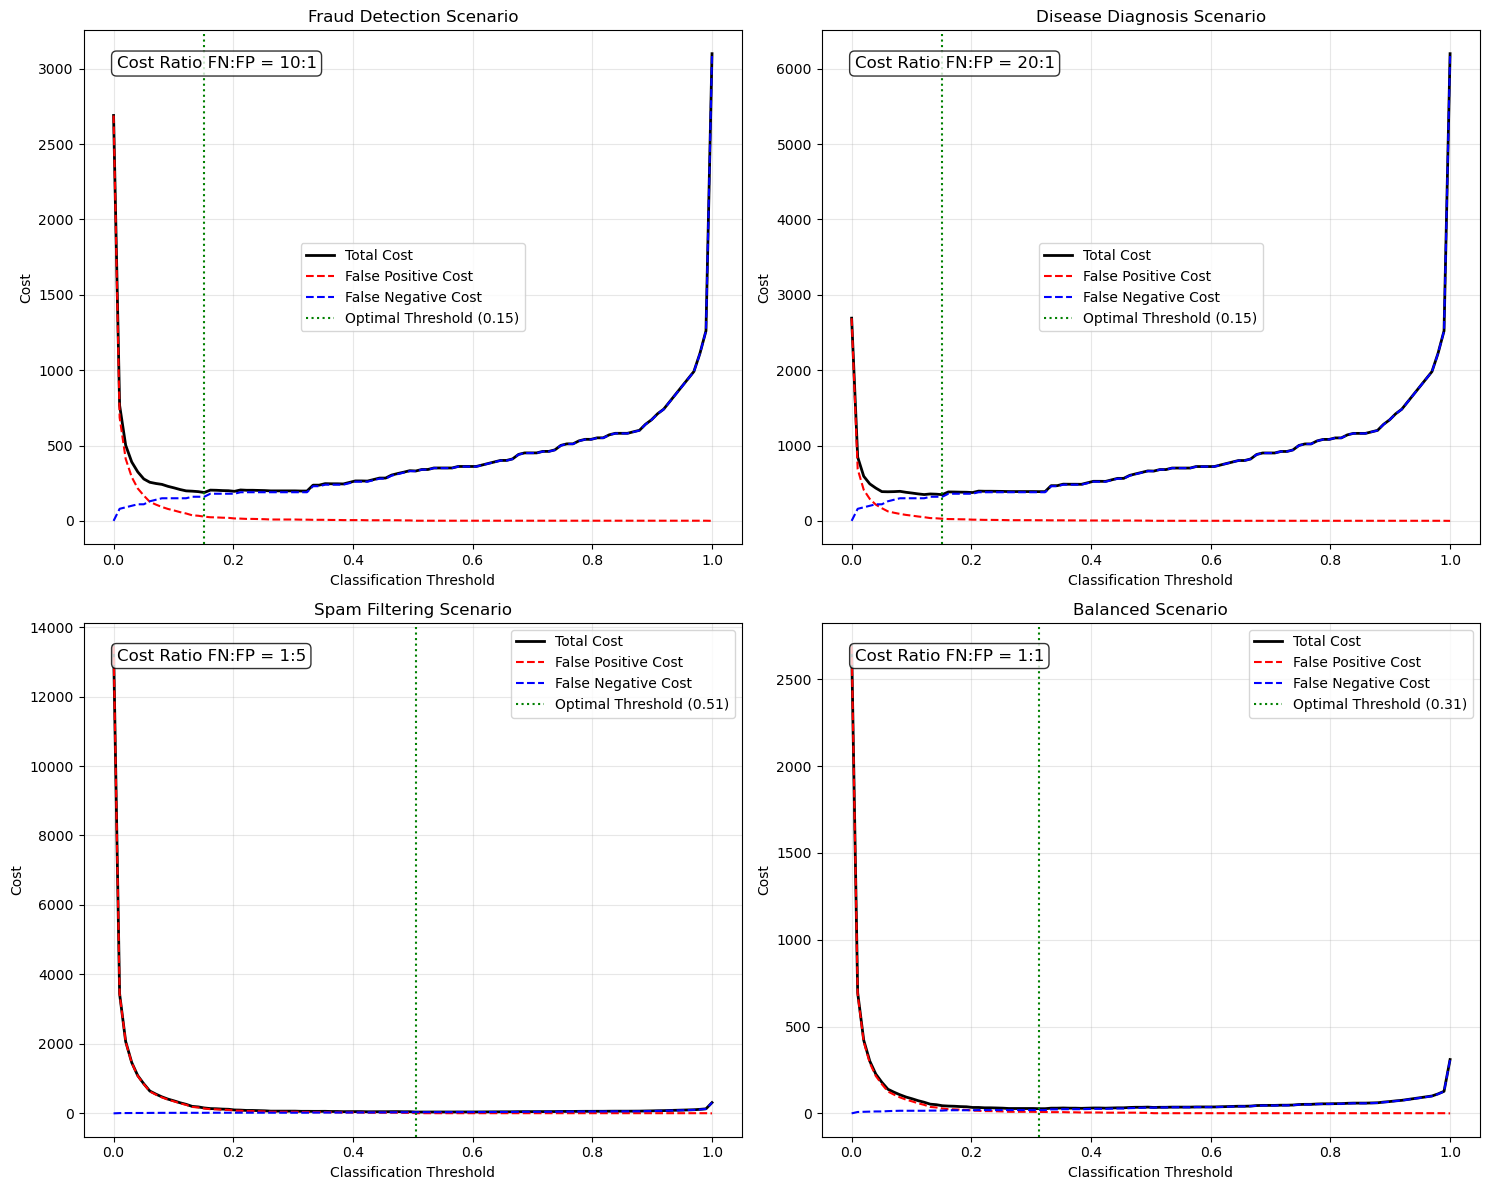

In [32]:
# Visualize business cost scenarios
def plot_business_scenarios():
    # Define scenarios
    scenarios = {
        'Fraud Detection': {'FP': 1, 'FN': 10},  # False negative (missed fraud) costs 10x more
        'Disease Diagnosis': {'FP': 1, 'FN': 20},  # False negative (missed diagnosis) costs 20x more
        'Spam Filtering': {'FP': 5, 'FN': 1},  # False positive (legitimate email as spam) costs 5x more
        'Balanced': {'FP': 1, 'FN': 1}  # Equal costs
    }
    
    # Create a figure with cost landscapes
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    axs = axs.flatten()
    
    # Define threshold grid
    thresholds = np.linspace(0, 1, 100)
    
    # For each scenario
    for i, (name, costs) in enumerate(scenarios.items()):
        # Calculate costs at different thresholds
        total_costs = []
        fp_costs = []
        fn_costs = []
        
        for threshold in thresholds:
            y_pred_t = (y_proba >= threshold).astype(int)
            cm_t = confusion_matrix(y_test, y_pred_t)
            tn, fp, fn, tp = cm_t.ravel()
            
            # Calculate costs
            fp_cost = fp * costs['FP']
            fn_cost = fn * costs['FN']
            total_cost = fp_cost + fn_cost
            
            total_costs.append(total_cost)
            fp_costs.append(fp_cost)
            fn_costs.append(fn_cost)
        
        # Find optimal threshold
        optimal_idx = np.argmin(total_costs)
        optimal_threshold = thresholds[optimal_idx]
        
        # Plot costs
        ax = axs[i]
        ax.plot(thresholds, total_costs, 'k-', linewidth=2, label='Total Cost')
        ax.plot(thresholds, fp_costs, 'r--', linewidth=1.5, label='False Positive Cost')
        ax.plot(thresholds, fn_costs, 'b--', linewidth=1.5, label='False Negative Cost')
        
        # Mark optimal threshold
        ax.axvline(x=optimal_threshold, color='green', linestyle=':', linewidth=1.5,
                  label=f'Optimal Threshold ({optimal_threshold:.2f})')
        
        # Annotate cost ratio
        ax.text(0.05, 0.95, f"Cost Ratio FN:FP = {costs['FN']}:{costs['FP']}", 
                transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel('Classification Threshold')
        ax.set_ylabel('Cost')
        ax.set_title(f'{name} Scenario')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot business scenarios
plot_business_scenarios()

## Knowledge Check

Let's test your understanding of evaluation metrics for imbalanced data:

1. **Multiple Choice**: Which of the following metrics is LEAST suitable for evaluating models on highly imbalanced datasets?
   a) F1-score
   b) Precision-Recall AUC
   c) Accuracy
   d) G-mean

In [ ]:
python
   # Answer
   print("c) Accuracy - It can be misleading for imbalanced datasets because it's dominated by the majority class.")

2. **True or False**: ROC curves are always preferable to PR curves for evaluating classifier performance.

In [ ]:
python
   # Answer
   print("False. PR curves are often more informative for imbalanced datasets as they focus on the minority class performance and are not affected by large numbers of true negatives.")

3. **Short Answer**: Why is the Precision-Recall curve more suitable than ROC curve for imbalanced datasets?

In [ ]:
python
   # Answer
   print("PR curves focus on the positive (minority) class performance by plotting precision vs. recall. They are not affected by the large number of true negatives in imbalanced datasets, which can make ROC curves appear overly optimistic.")

4. **Application**: For a credit card fraud detection system with a 0.5% fraud rate, which evaluation metric would you prioritize and why?

In [ ]:
python
   # Answer
   print("Recall or PR AUC would be most appropriate. In fraud detection, false negatives (missed frauds) are typically much more costly than false positives. Recall measures how many actual frauds we catch, while PR AUC provides a comprehensive assessment of precision-recall tradeoffs across thresholds.")

## Summary

In this section, we've explored evaluation metrics for imbalanced data:

1. **Standard metrics** like accuracy can be misleading for imbalanced datasets because they're dominated by the majority class.

2. **Confusion matrix-based metrics** provide more insight:
   - **Precision**: how many of the predicted positives are actually positive
   - **Recall**: how many of the actual positives are correctly identified
   - **F1-score**: harmonic mean of precision and recall

3. **Precision-Recall (PR) curves** are particularly useful for imbalanced data:
   - Plot precision vs. recall for different classification thresholds
   - Focus on minority class performance
   - Not affected by large numbers of true negatives
   - Area under the PR curve (AUC-PR) provides a single summary metric

4. **Additional specialized metrics** can be helpful:
   - Balanced Accuracy: average of sensitivity and specificity
   - G-mean: geometric mean of sensitivity and specificity
   - Matthews Correlation Coefficient (MCC): balanced measure even with class imbalance

5. **Choosing the right metric** depends on the business context and the relative costs of different error types.

When working with imbalanced datasets, it's crucial to:
- Always look beyond accuracy
- Consider the specific business costs of false positives vs. false negatives
- Use PR curves and PR AUC for comprehensive evaluation
- Remember that different thresholds allow you to trade off precision vs. recall based on your needs

In the next section, we'll apply these concepts in a hands-on lab to evaluate models on an imbalanced dataset.